# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df =pd.read_csv("data.csv")

In [2]:
# Five first rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

In [3]:
# Age distribution

aga_summary = df["age"].describe()
aga_summary

count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

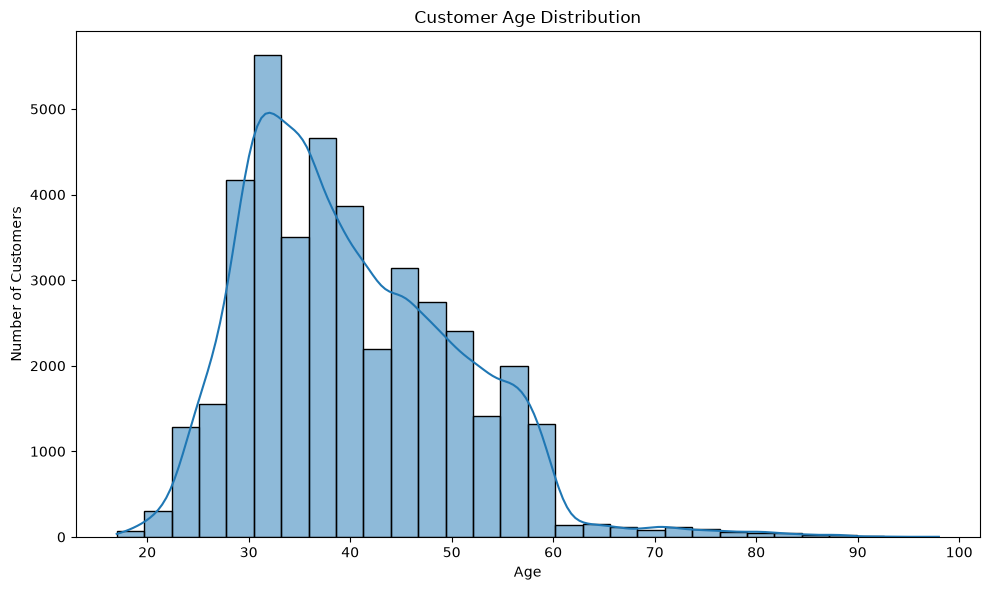

In [4]:
# Age Distribution Visualization
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [5]:
# Age Distribution by Subscription Outcome
age_by_subscription =(
    df.groupby("y")["age"]
      .agg(["count","mean","median","min","max"])
)
age_by_subscription

,count,mean,median,min,max
y,,,,,
no,36548,39.911185,38.0,17,95
yes,4640,40.913147,37.0,17,98


In [6]:
# Age Group Analysis
age_bins=[16,25,35,45,55,65,100]
age_labels=[
    "17-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_group_summary=(
    df["age_group"]
    .value_counts()
    .sort_index()
)

age_group_summary

age_group
17-25     1666
26-35    14847
36-45    12844
46-55     8249
56-65     2963
66+        619
Name: count, dtype: int64

In [7]:
# Subscription Rate by Age Group
age_subscription=pd.crosstab(
    df["age_group"],
    df["y"],
    normalize="index"
).mul(100)

age_subscription

y,no,yes
age_group,,
17-25,79.051621,20.948379
26-35,88.280461,11.719539
36-45,91.490190,8.509810
46-55,91.308037,8.691963
56-65,84.778940,15.221060
66+,53.150242,46.849758


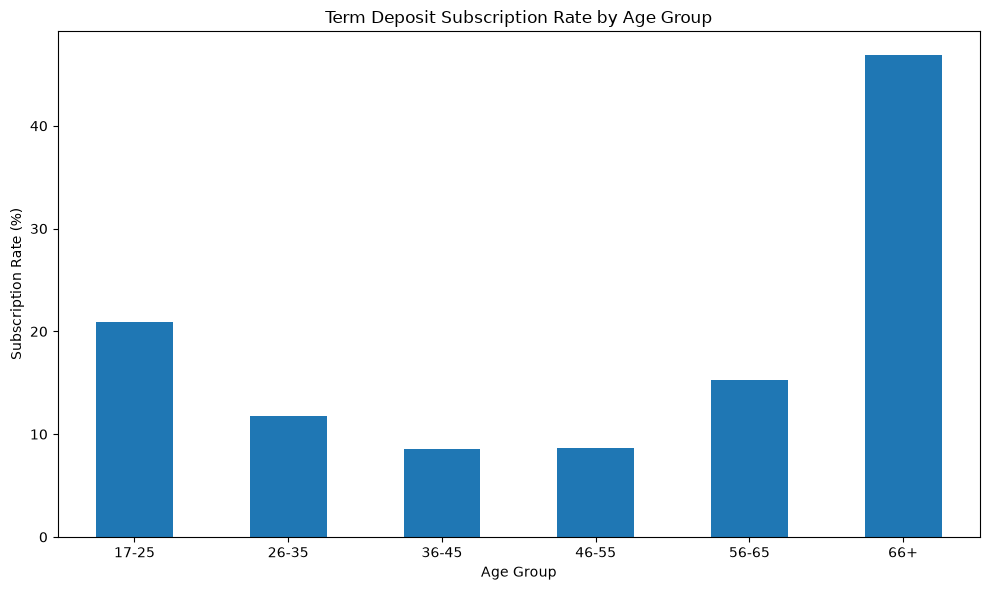

In [8]:
# Visualize Subscription Rate by Age Group
age_subscription["yes"].plot(
    kind="bar",
    figsize=(10,6)
)
plt.title("Term Deposit Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Job distribution
job_distribution=(
    df["job"]
    .value_counts()
)
job_distribution


job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

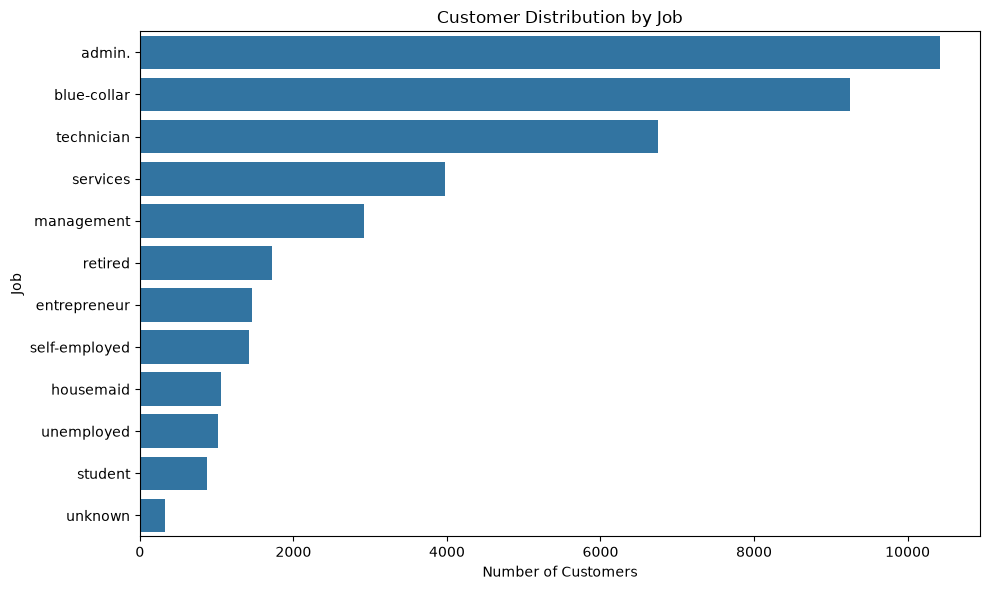

In [10]:
# Job Distribution Visualization
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

plt.title("Customer Distribution by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")
plt.tight_layout()
plt.show()

In [11]:
# Job Distribution and Subscription Outcome
job_subscription = pd.crosstab(
    df["job"],
    df["y"]
)

job_subscription

y,no,yes
job,,
admin.,9070,1352
blue-collar,8616,638
entrepreneur,1332,124
housemaid,954,106
management,2596,328
retired,1286,434
self-employed,1272,149
services,3646,323
student,600,275


In [12]:
# Subscription Rate by Job
job_subscription_rate=pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
).mul(100)

job_subscription_rate

y,no,yes
job,,
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070
student,68.571429,31.428571


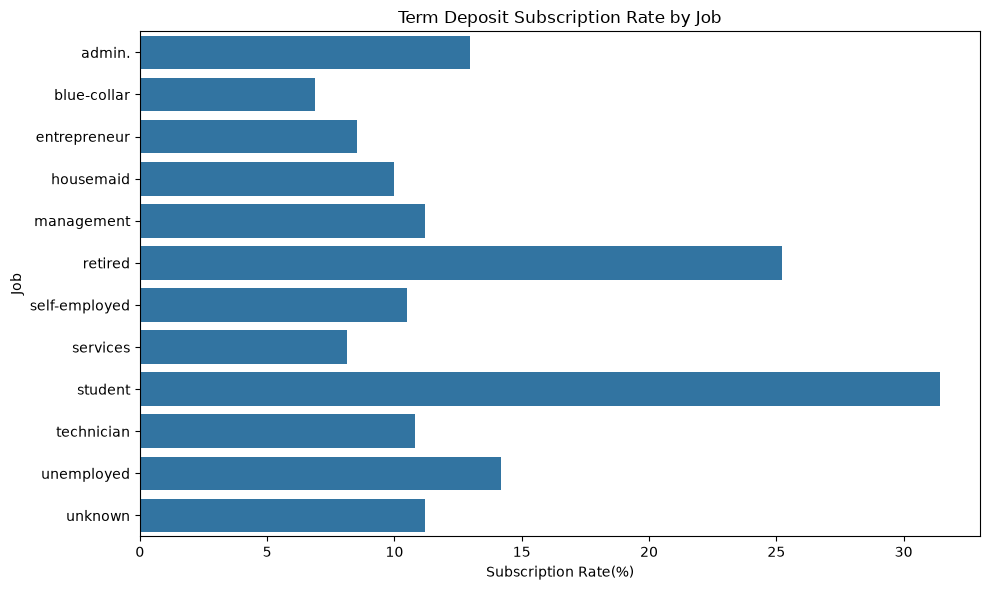

In [13]:
# Visualise Job Subscription Rate
plt.figure(figsize=(10,6))

sns.barplot(
    data=(
        job_subscription_rate
        .reset_index()
        .rename(columns={"yes":"subscription_rate"})
    ),
    x="subscription_rate",
    y="job"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate(%)")
plt.ylabel("Job")
plt.tight_layout()
plt.show()

## Balance & Deposit Trends

In [14]:
# Check all availabe columns
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y',
 'age_group']

In [15]:
"balance" in df.columns

False

In [16]:
# Verify the Availabe Deposit Subscription Variable
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [17]:
# Overall Deposit Subscription Rate
subscription_rate = (
    df["y"].value_counts(normalize=True)
    .mul(100)
)

subscription_rate

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

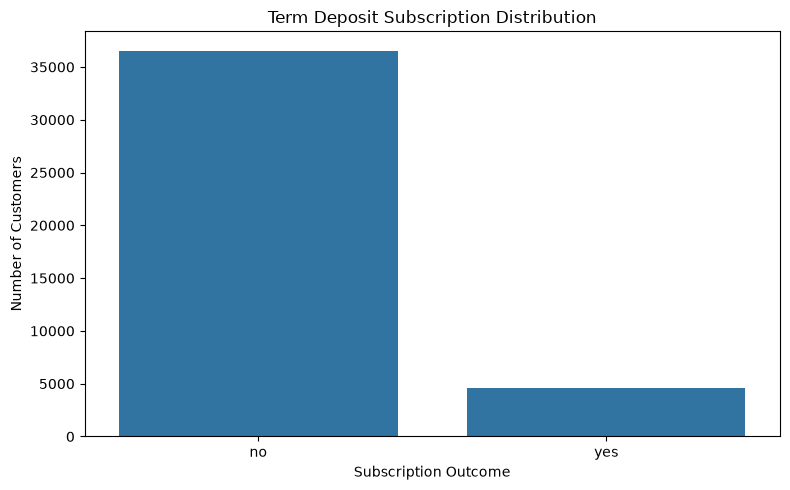

In [18]:
# Visualize Deposit Subscription
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="y"
)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [19]:
# Data Availability Audit
numerical_columns=df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_columns

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

## Campaign Effectiveness

In [20]:
# Contact method analysis
# The dataset contains a categorical variable named contact, representing the contact communication method reordered fro the campaign. 
# The objective is the determine whether subscription outcomes differ between the available contact methods.
contact_distribution=df["contact"].value_counts()
contact_distribution

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

In [21]:
# Contact Method Versus Subscription
contact_subscription = pd.crosstab(
    df["contact"],df["y"]
)
contact_subscription

y,no,yes
contact,,
cellular,22291,3853
telephone,14257,787


In [22]:
# Subscription Rate by Contact Method
contact_subscription_rate=pd.crosstab(
    df["contact"],
    df["y"],
    normalize="index"
).mul(100)
contact_subscription_rate

y,no,yes
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


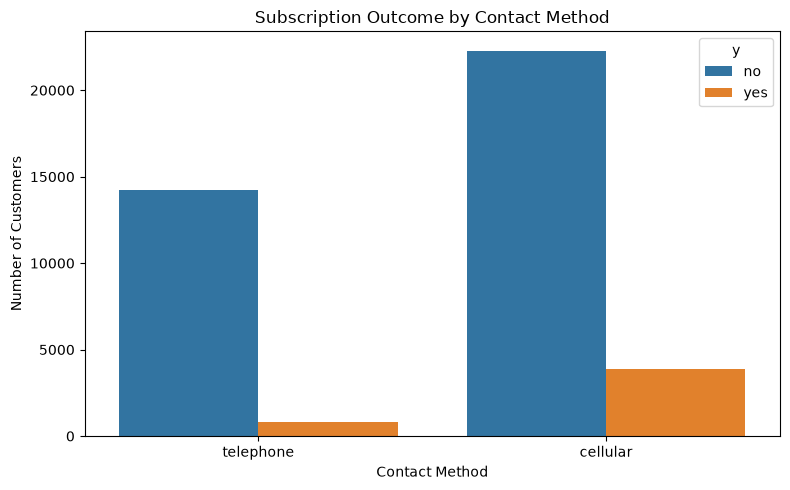

In [23]:
# Contact Method Visualization
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="contact",
    hue="y"
)

plt.title("Subscription Outcome by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [24]:
# Campaign Contact Statistics by Subscription
campaign_by_subscription=(
    df.groupby("y")["campaign"]
      .agg(["count","mean","median","min","max"])
)

campaign_by_subscription

,count,mean,median,min,max
y,,,,,
no,36548,2.633085,2.0,1,56
yes,4640,2.051724,2.0,1,23


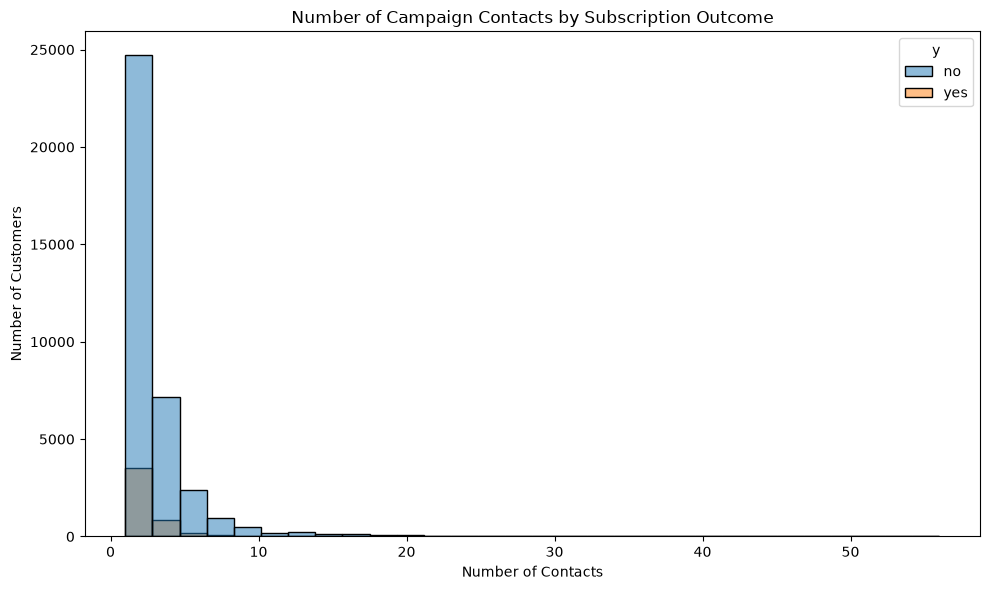

In [25]:
#Campaign Contact Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="campaign",
    hue="y",
    bins=30,
    multiple="layer"
)

plt.title("Number of Campaign Contacts by Subscription Outcome")
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [26]:
# Subscription Rate by Number of Contacts
campaign_subscription_rate=pd.crosstab(
    df["campaign"],
    df["y"],
    normalize="index"
).mul(100)

campaign_subscription_rate

y,no,yes
campaign,,
1,86.962929,13.037071
2,88.543046,11.456954
3,89.252949,10.747051
4,90.607318,9.392682
5,92.495310,7.504690
6,92.339122,7.660878
7,93.958665,6.041335
8,95.750000,4.250000
9,93.992933,6.007067


In [27]:
# Call Duration Analysis
duration_by_subscription=(
    df.groupby("y")["duration"]
      .agg(["count","mean","median","min","max"])
)

duration_by_subscription

,count,mean,median,min,max
y,,,,,
no,36548,220.844807,163.5,0,4918
yes,4640,553.191164,449.0,37,4199


## Correlation Heatmap

In [28]:
# Identify Numerical Variables
numerical_columns=df.select_dtypes(
    include=np.number
).columns.tolist()

numerical_columns

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [29]:
# Calculate the Correlation Matrix
correlation_matrix=(
    df[numerical_columns]
    .corr()
)

correlation_matrix

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.000000,-0.000866,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725
duration,-0.000866,1.000000,-0.071699,-0.047577,0.020640,-0.027968,0.005312,-0.008173,-0.032897,-0.044703
campaign,0.004594,-0.071699,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095
pdays,-0.034369,-0.047577,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605
previous,0.024365,0.020640,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333
emp.var.rate,-0.000371,-0.027968,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970
cons.price.idx,0.000857,0.005312,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034
cons.conf.idx,0.129372,-0.008173,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513
euribor3m,0.010767,-0.032897,0.135133,0.296899,-0.454494,0.972245,0.688230,0.277686,1.000000,0.945154
nr.employed,-0.017725,-0.044703,0.144095,0.372605,-0.501333,0.906970,0.522034,0.100513,0.945154,1.000000


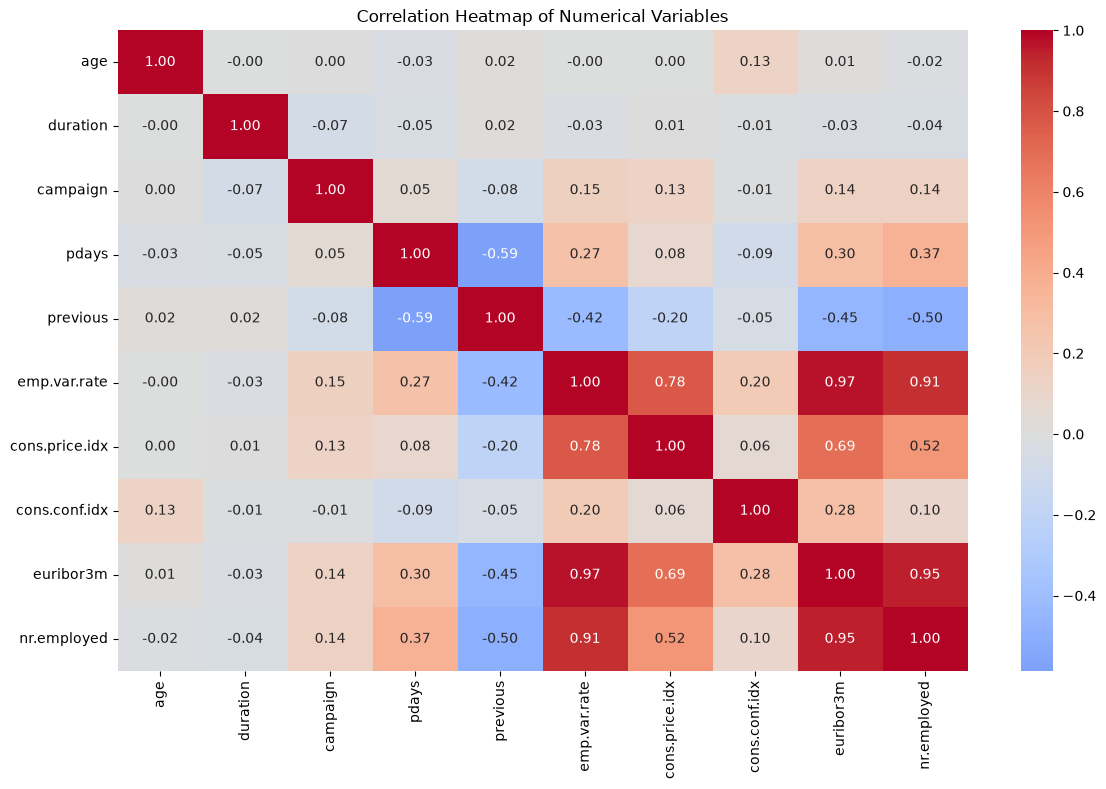

In [30]:
# Visualize the Correlation Matrix
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

## Predictive Modeling (Logistic Regression)

In [ ]:
# Define the Machine - Learning Problem
# The model attempts to estimate: P(y=yes|X), where X represents the customer, campaign, previous-contact, and economic features.


In [32]:
# Define Features and Target
# The predictor matrix is created by removing this target:
X=df.drop(columns=["y"])
y=df["y"].map({
    "no":0,
    "yes":1
})

In [35]:
# Identify Numerical and Categorical Predictors
numerical_columns=X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns=X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns")
print(categorical_columns)

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


C:\Users\Ravindra Pal\AppData\Local\Temp\ipykernel_13120\3883598821.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns=X.select_dtypes(


In [36]:
# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=20,
    random_state=42,
    stratify=y
)

In [37]:
# Encode Categorical Variables
from sklearn.preprocessing import OneHotEncoder

categorical_transformer=OneHotEncoder(
    drop='frist',
    handle_unknown="ignore"
)

In [38]:
# Scale Numerical Variables
from sklearn.preprocessing import StandardScaler
numerical_transformer=StandardScaler()

In [39]:
# Building the Preprocessing Pipeline
from sklearn.compose import ColumnTransformer

preprocessor=ColumnTransformer(
    transformers=[
        (
            "num",StandardScaler(),numerical_columns
        ),
        (
            "cat",OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

In [41]:
# Build Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model=Pipeline(
    steps=[
        (
            "preprocess",
            preprocessor
        ),
        (
            "logreg",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [42]:
# Train the Model
model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('logreg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['age','job','marital',...,'euribor3m','nr.employed','age_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaini

In [43]:
# Generate Predictions
y_pred=model.predict(
    X_test
)

In [44]:
y_probability=model.predict_proba(
   X_test
)[:,1]

In [45]:
# Evaluate the Model
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy=accuracy_score(
    y_test,
    y_pred
)

precision=precision_score(
    y_test,
    y_pred
)

recall=recall_score(
    y_test,
    y_pred
)

f1=f1_score(
    y_test,
    y_pred
)

roc_auc=roc_auc_score(
    y_test,
    y_probability
)

In [46]:
# Interpretation of Accuracy: Accuracy=Correct Predictions/Total Predictions
# The model correctly classifies approximately: 91.62%.

# Interpretation of Precision: Precision=TP/(TP+FP)
# The model achieves: 70.95%

# Interpretation of Recall: Recall=TP/(TP+FN)
# The result is: 43.43%.

# Interpretation of F1-Score: F1=2(PrecisionxRecall)/(Precision+Recall)
# The Model obtains : F1=0.5388

# Interpretation of ROC-AUC
# ROC-AUC evaluates the model's ability to rank positive obervations above negative observations across classification threesolds.
# The model achieves: ROC-AUC=0.9425



In [48]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
confusion_matrix_result=confusion_matrix(
    y_test,
    y_pred
)

confusion_matrix_result

array([[18,  0],
       [ 1,  1]])

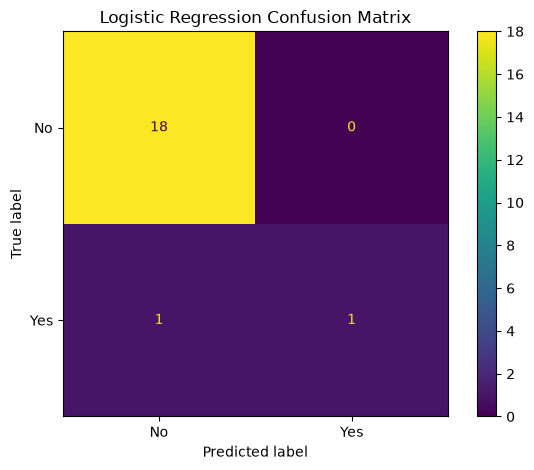

In [49]:
# Visualize the Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No",
        "Yes"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [51]:
# Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "no",
            "yes"
        ]
    )
)

              precision    recall  f1-score   support

          no       0.95      1.00      0.97        18
         yes       1.00      0.50      0.67         2

    accuracy                           0.95        20
   macro avg       0.97      0.75      0.82        20
weighted avg       0.95      0.95      0.94        20



In [ ]:
# Critical Modeling Limitation: duration
# The dataset contains the variable: duration.
# We observed that subscribers have substantially longer contact durations than non-subscribers.
# However, duration represents information generated during the customer contact.
# If the intended business use is: "Predict whether a customer will subscribe before contacting the customer", then duration would not yet be known.
# Using it could therefore create: "Information Leakage" for a true pre-contact targeting model.
# A deployment-oriented future version should evaluate a second model without duration if predictions are intended to be made before customer contact.


## Key Takeaways
- Certain age groups and job categories are more likely to subscribe.
- Higher balances correlate with higher subscription rates.
- Cellular contact is more effective than telephone.
- Campaign duration and number of contacts influence outcomes.
- Logistic regression shows which features are strongest predictors.